# $\Lambda_b^0 \to \Lambda_c^+ \pi^-$ control fit (superseded)

$\Lambda_b^0 \to \Lambda_c^+\pi^-$ leaks into the $D^+\pi^-$ sample when the proton from $\Lambda_c^+ \to pK^-\pi^+$ is misidentified as a pion: the three-track combination then satisfies the $D^+$ mass window and daughter PID requirements, and the genuine bachelor pion passes the pion-like selection.

**This is not the fit used in the measurement.** It is an earlier standalone version, kept for the record. It differs from the final treatment in three ways, and the final version lives in section 1.6 of notebook 03:

- the signal is parametrised as Hypatia + Gaussian here, and as a Johnson $S_U$ in notebook 03;
- no $\Lambda_c^+$ daughter PID requirement is applied, so the sample is much larger (14.1M candidates in the window against 573k) and the fitted yield is correspondingly different;
- **the minimisation did not converge.** MIGRAD returns `status = 3` with Edm = 5.26 against a tolerance of 0.01, `horn_b_sc` sits on its upper limit, and `sigma_sc` sits on its lower limit with an uncertainty larger than its value. The outputs below are left in place rather than removed.

The number that enters the analysis is $N^{\mathrm{ctrl}}_{\Lambda_b^0} = 348274 \pm 649$ from notebook 03, where the fit converges with `status=0`, `covQual=2`. Figure 6 of the report is produced there as well.


In [ ]:
# =============================================================
# RooFit message service
# -------------------------------------------------------------
# RooFit prints thousands of INFO and Eval-topic messages during
# fitting: integrator setup, plot-projection ranges, and warnings
# emitted while MIGRAD probes regions where a PDF evaluates
# negative. The minimiser recovers from those on its own - they
# are not fit failures.
#
# ERROR and FATAL are deliberately NOT suppressed, so genuine
# problems still surface. Comment this cell out if a fit
# misbehaves and the full trace is needed.
# =============================================================
import ROOT

_msg = ROOT.RooMsgService.instance()
_msg.setGlobalKillBelow(ROOT.RooFit.WARNING)
_msg.setSilentMode(True)
for _topic in (ROOT.RooFit.Eval, ROOT.RooFit.NumIntegration,
               ROOT.RooFit.Minimization, ROOT.RooFit.Plotting):
    for _s in range(_msg.numStreams()):
        _msg.getStream(_s).removeTopic(_topic)
_msg.setStreamStatus(1, False)

print("RooFit message service quietened (WARNING and above still shown).")


In [1]:
# Standard Library Imports
import os
import time
import numpy as np
import uproot
import matplotlib.pyplot as plt
# ROOT and RooFit Imports
import ROOT
from ROOT import RooFit as RF
from ROOT import (
    kBlue, kRed, kViolet, kMagenta, kOrange, kGreen, kBlack,
    kAzure, kFullCircle, kDashed, kDotted, kDashDotted
)
# IPython Display Utilities
from IPython.display import Image as IPyImage, display as ipydisplay
# ROOT Configuration
ROOT.gROOT.SetBatch(True)       # Run ROOT in batch mode (no GUI)
ROOT.EnableImplicitMT()         # Enable multi-threading
# Load Custom Library and Include Paths
# Load custom HILL/HORNS PDFs (once)
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))


Welcome to JupyROOT 6.30/02
Custom PDFs: True True



## Control fit to $m(\Lambda_c^+ \pi^-)$

The signal is a Hypatia plus a Gaussian sharing a common mean, with the Hypatia tail parameters fixed to Table 29 of the report. The combinatorial background is a constant plus an exponential. Two HORNS components cover the partially reconstructed modes $\Lambda_b^0 \to \Lambda_c^+\rho^-$ and $\Lambda_b^0 \to \Sigma_c\pi$, both missing a $\pi^0$; they are separated by letting the $\Sigma_c$ endpoint float in a narrow band, since with a shared endpoint the two shapes are degenerate.

No $\Lambda_c^+ \to pK^-\pi^+$ daughter PID requirement is applied at this stage. Adding it, together with the Johnson $S_U$ signal shape, is what distinguishes the version in notebook 03.


[INFO] Hypatia: RooHypatia2
[INFO] HORNS:   RooHORNSdini
[INFO] Entries in window: 14113719

=== FITTED YIELDS ===
Nsig   = 570677 ± 2490
Ncomb  = 13329527 ± 12364
Nrho   = 159943 ± 7258
Nsigmc = 53589 ± 5098

=== KEY PARTRECO SHAPES ===
b_rho (fixed) = 5480.600
b_sc          = 5579.999 ± 0.281
sigma_rho     = 18.286 ± 1.744
sigma_sc      = 6.022 ± 14.846

[INFO] Saved plot: Lb2LcPi_fit_5350_6000_2part_bsc_lin_log_pull.pdf
[INFO] Saved workspace: Lb2LcPi_fit_5350_6000_2part_bsc_workspace.root
Minuit2Minimizer: Minimize with max-calls 6500 convergence for edm < 1 strategy 1
Minuit2Minimizer : Invalid Minimum - status = 3
FVAL  = -1.26979e+08
Edm   = 5.2585
Nfcn  = 2611

  RooFitResult: minimized FCN value: -1.26979e+08, estimated distance to minimum: 1.51887
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=-1 HESSE=3 

    Constant Parameter    Value     
  --------------------  ------------
                    a1    1.6220e+0

Warning in <Minuit2>: DavidonErrorUpdator delgam < 0 : first derivatives increasing along search line
Warning in <Minuit2>: VariableMetricBuilder Matrix not pos.def, gdel = 20.6328 > 0
Warning in <Minuit2>: MnPosDef Added to diagonal of Error matrix a value 0.500006
Warning in <Minuit2>: VariableMetricBuilder gdel = -8.40705e+08
Warning in <Minuit2>: DavidonErrorUpdator delgam < 0 : first derivatives increasing along search line
Warning in <Minuit2>: VariableMetricBuilder Matrix not pos.def., try to make pos.def.
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.691745
Warning in <Minuit2>: DavidonErrorUpdator delgam < 0 : first derivatives increasing along search line
Warning in <Minuit2>: VariableMetricBuilder Matrix not pos.def, gdel = 160.667 > 0
Warning in <Minuit2>: MnPosDef Added to diagonal of Error matrix a value 0.500187
Warning in <Minuit2>: VariableMetricBuilder gdel = -1.94563e+07
Warning in <Minuit2>: VariableMetricBuilder No improvement in line

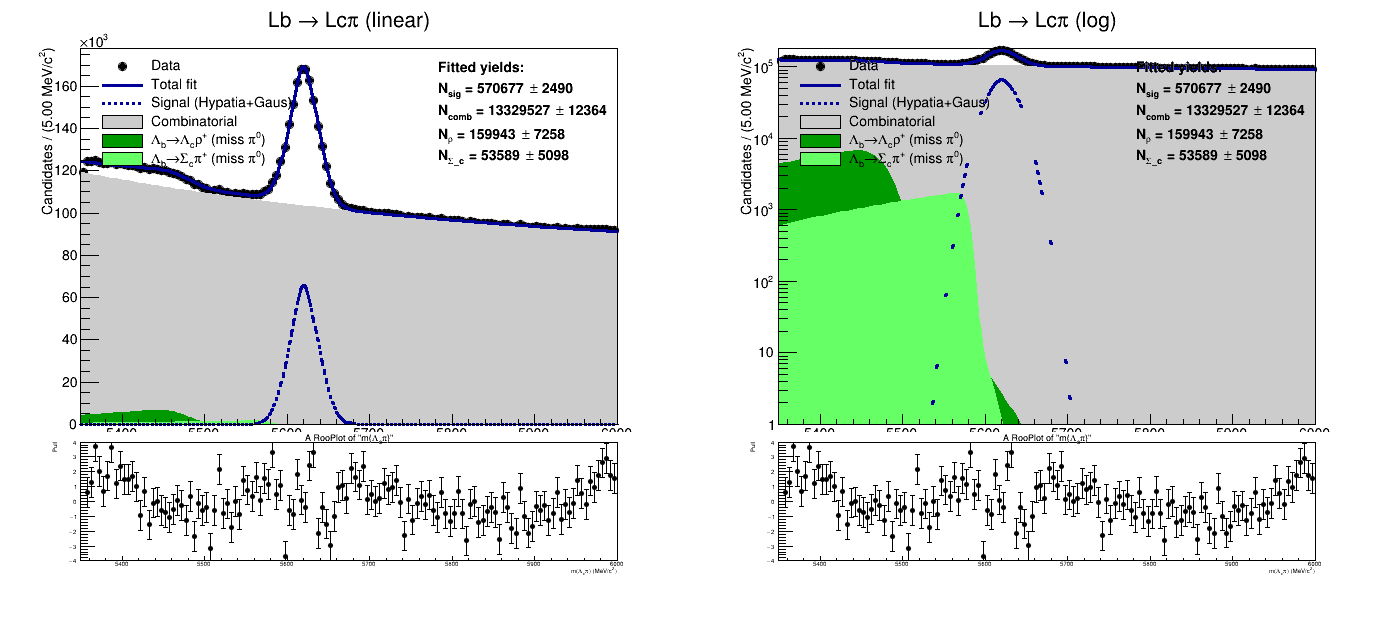

In [5]:
"""
Binned fit to m(Lc pi) over 5350-6000 MeV/c^2, single combined sample.

Model
  Signal      Hypatia + Gaussian on a common mean, Hypatia tails fixed to
              Table 29 of the report.
  Comb.       constant + exponential.
  Part-reco   two RooHORNSdini components, for Lb -> Lc rho+ and
              Lb -> Sigma_c pi, both missing a pi0. The Sigma_c component
              is given its own endpoint b_sc, floating in a narrow band:
              with a shared endpoint the two shapes are degenerate and
              Nsigmc is unconstrained.

Drawn objects are held in KEEP. PyROOT will otherwise collect them while
the canvas is still open, which segfaults the kernel.

Writes the linear and logarithmic panels with pulls, and a workspace
holding the data, the model and the fit result.
"""

import numpy as np
import uproot
import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)

# --------------------------
# Inputs
# --------------------------
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block7/new_files/tuple_Lb2LcPi_down_s24c4_block7_range_BDT.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block8/new_files/tuple_Lb2LcPi_up_s24c4_block8_range_BDT.root",
]
TREENAME = "Tuple/DecayTree"
MASSBR   = "lab0_MASS"

MASS_LO, MASS_HI = 5350.0, 6000.0
NBINS = 130  # ~5 MeV/bin

OUTPDF  = "Lb2LcPi_fit_5350_6000_2part_bsc_lin_log_pull.pdf"
OUTROOT = "Lb2LcPi_fit_5350_6000_2part_bsc_workspace.root"

# holds references to drawn objects for the lifetime of the canvas
KEEP = []


# --------------------------
# Helpers
# --------------------------
def get_class(name_candidates):
    for n in name_candidates:
        cls = getattr(ROOT, n, None)
        if cls is not None:
            return cls, n
    return None, None

def require_pdf_class(name_candidates, help_msg):
    cls, used = get_class(name_candidates)
    if cls is None:
        raise RuntimeError(f"{help_msg} Missing: {name_candidates}")
    return cls, used


# --------------------------
# Get required PDFs
# --------------------------
IpatiaCls, IPATIA_NAME = require_pdf_class(
    ["RooIpatia2", "RooHypatia2", "RooIpatia", "RooHypatia"],
    "Need RooHypatia2/RooIpatia2"
)
HornsCls, HORNS_NAME = require_pdf_class(
    ["RooHORNSdini", "RooHornsDini", "RooHORNSDini"],
    "Need RooHORNSdini"
)

print(f"[INFO] Hypatia: {IPATIA_NAME}")
print(f"[INFO] HORNS:   {HORNS_NAME}")


# --------------------------
# Read & histogram
# --------------------------
mass_list = []
for path in FILES:
    with uproot.open(path) as f:
        t = f[TREENAME]
        mm = t.arrays([MASSBR], library="np")[MASSBR].astype(np.float64)
        mass_list.append(mm)

mass_all = np.concatenate(mass_list)
mass_all = mass_all[(mass_all > MASS_LO) & (mass_all < MASS_HI)]
Ntot = len(mass_all)
print(f"[INFO] Entries in window: {Ntot}")

edges = np.linspace(MASS_LO, MASS_HI, NBINS + 1)
counts, _ = np.histogram(mass_all, bins=edges)

h = ROOT.TH1D("h_data", "h_data", NBINS, MASS_LO, MASS_HI)
for i in range(NBINS):
    c = float(counts[i])
    h.SetBinContent(i + 1, c)
    h.SetBinError(i + 1, np.sqrt(c) if c > 0 else 1.0)

m = ROOT.RooRealVar("BeautyMass", "m(#Lambda_{c}#pi)", MASS_LO, MASS_HI, "MeV/c^{2}")
m.setBins(NBINS)
data_hist = ROOT.RooDataHist("data_hist", "data_hist", ROOT.RooArgList(m), h)
binw = (MASS_HI - MASS_LO) / NBINS


# --------------------------
# Signal: Hypatia tails fixed (paper Table 29)
# --------------------------
P = dict(a1=1.622, a2=1.956, lam=-6.8, n1=1.151, n2=3.229, mu=5619.017)

beta = ROOT.RooRealVar("beta", "beta", 0.0); beta.setConstant(True)
zeta = ROOT.RooRealVar("zeta", "zeta", 0.0); zeta.setConstant(True)

a1   = ROOT.RooRealVar("a1", "a1", P["a1"], 0.0, 10.0); a1.setConstant(True)
a2   = ROOT.RooRealVar("a2", "a2", P["a2"], 0.0, 10.0); a2.setConstant(True)
lmbd = ROOT.RooRealVar("lambda", "lambda", P["lam"], -100.0, -1e-6); lmbd.setConstant(True)
n1   = ROOT.RooRealVar("n1", "n1", P["n1"], 0.0, 50.0); n1.setConstant(True)
n2   = ROOT.RooRealVar("n2", "n2", P["n2"], 0.0, 50.0); n2.setConstant(True)

mu = ROOT.RooRealVar("mu", "mu", P["mu"], 5600.0, 5640.0)

sigH = ROOT.RooRealVar("sigH", "sigH", 14.5, 8.0, 25.0)
sigG = ROOT.RooRealVar("sigG", "sigG", 13.0, 8.0, 25.0)
fG   = ROOT.RooRealVar("fG",   "fG",   0.35, 0.0, 1.0)

hyp  = IpatiaCls("hyp", "hypatia", m, lmbd, zeta, beta, sigH, mu, a1, n1, a2, n2)
gaus = ROOT.RooGaussian("gaus", "gaus", m, mu, sigG)
sig_pdf = ROOT.RooAddPdf("sig", "signal", ROOT.RooArgList(gaus, hyp), ROOT.RooArgList(fG))


# --------------------------
# Comb: const + exp
# --------------------------
c = ROOT.RooRealVar("c", "c", -1.8e-3, -5e-2, 0.0)
exp_pdf = ROOT.RooExponential("combExp", "comb exp", m, c)
const_pdf = ROOT.RooPolynomial("combC", "comb const", m)
fC = ROOT.RooRealVar("fC", "fC", 0.2, 0.0, 1.0)
comb_pdf = ROOT.RooAddPdf("comb", "comb (const+exp)", ROOT.RooArgList(const_pdf, exp_pdf), ROOT.RooArgList(fC))


# --------------------------
# PartReco: TWO HORNS with distinguishable endpoints
# --------------------------
horn_a   = ROOT.RooRealVar("horn_a", "a", 4500.0);  horn_a.setConstant(True)
horn_csi = ROOT.RooRealVar("horn_csi", "csi", 1.0); horn_csi.setConstant(True)

# rho endpoint fixed to the published value
horn_b_rho = ROOT.RooRealVar("horn_b_rho", "b_rho", 5480.60); horn_b_rho.setConstant(True)

# Sigma_c endpoint floats in a narrow physical band; this is what keeps
# Nsigmc from running away against the rho component
horn_b_sc = ROOT.RooRealVar("horn_b_sc", "b_sc", 5520.0, 5460.0, 5580.0)

shift_rho = ROOT.RooRealVar("shift_rho", "shift_rho", 0.0); shift_rho.setConstant(True)
shift_sc  = ROOT.RooRealVar("shift_sc",  "shift_sc",  0.0); shift_sc.setConstant(True)

sigma_rho = ROOT.RooRealVar("sigma_rho", "sigma_rho", 18.0, 8.0, 35.0)
sigma_sc  = ROOT.RooRealVar("sigma_sc",  "sigma_sc",  12.0, 6.0, 30.0)

ratio_sigma = ROOT.RooRealVar("ratio_sigma", "ratio_sigma", 3.49);   ratio_sigma.setConstant(True)
frac_sigma  = ROOT.RooRealVar("frac_sigma",  "frac_sigma",  0.9743); frac_sigma.setConstant(True)

part_rho = HornsCls("part_rho", "partReco rho", m, horn_a, horn_b_rho, horn_csi, shift_rho, sigma_rho, ratio_sigma, frac_sigma)
part_sc  = HornsCls("part_sc",  "partReco sigmac", m, horn_a, horn_b_sc,  horn_csi, shift_sc,  sigma_sc,  ratio_sigma, frac_sigma)


# --------------------------
# Extended yields
# --------------------------
Nsig   = ROOT.RooRealVar("Nsig",   "Nsig",   0.10*Ntot, 0.0, 2.0*Ntot)
Ncomb  = ROOT.RooRealVar("Ncomb",  "Ncomb",  0.75*Ntot, 0.0, 2.0*Ntot)
Nrho   = ROOT.RooRealVar("Nrho",   "Nrho",   0.10*Ntot, 0.0, 2.0*Ntot)
Nsigmc = ROOT.RooRealVar("Nsigmc", "Nsigmc", 0.05*Ntot, 0.0, 2.0*Ntot)

model = ROOT.RooAddPdf(
    "model", "total model",
    ROOT.RooArgList(sig_pdf, comb_pdf, part_rho, part_sc),
    ROOT.RooArgList(Nsig, Ncomb, Nrho, Nsigmc)
)


# --------------------------
# Fit
# --------------------------
fitres = model.fitTo(
    data_hist,
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(True),
)
fitres.Print("v")

print("\n=== FITTED YIELDS ===")
print(f"Nsig   = {Nsig.getVal():.0f} ± {Nsig.getError():.0f}")
print(f"Ncomb  = {Ncomb.getVal():.0f} ± {Ncomb.getError():.0f}")
print(f"Nrho   = {Nrho.getVal():.0f} ± {Nrho.getError():.0f}")
print(f"Nsigmc = {Nsigmc.getVal():.0f} ± {Nsigmc.getError():.0f}")

print("\n=== KEY PARTRECO SHAPES ===")
print(f"b_rho (fixed) = {horn_b_rho.getVal():.3f}")
print(f"b_sc          = {horn_b_sc.getVal():.3f} ± {horn_b_sc.getError():.3f}")
print(f"sigma_rho     = {sigma_rho.getVal():.3f} ± {sigma_rho.getError():.3f}")
print(f"sigma_sc      = {sigma_sc.getVal():.3f} ± {sigma_sc.getError():.3f}")


# --------------------------
# Plotting: frames, pulls, legend, yield box
# --------------------------
COL_COMB = ROOT.kGray
COL_RHO  = ROOT.kGreen + 2
COL_SC   = ROOT.kGreen - 7
COL_TOT  = ROOT.kBlue + 2
COL_SIG  = ROOT.kBlue + 2

def make_pull_frame(frame):
    hpull = frame.pullHist("data", "model", True)
    hpull.SetMarkerStyle(20)
    hpull.SetMarkerSize(0.6)
    pf = m.frame()
    pf.addPlotable(hpull, "P")
    pf.SetYTitle("Pull")
    pf.SetMinimum(-4)
    pf.SetMaximum(4)
    return pf

def draw_frame(title, logy=False):
    frame = m.frame(ROOT.RooFit.Title(title))
    data_hist.plotOn(frame, ROOT.RooFit.Name("data"), ROOT.RooFit.DataError(ROOT.RooAbsData.SumW2))

    model.plotOn(frame, ROOT.RooFit.Components("comb"),
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_COMB))
    model.plotOn(frame, ROOT.RooFit.Components("part_rho"),
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_RHO))
    model.plotOn(frame, ROOT.RooFit.Components("part_sc"),
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_SC))

    model.plotOn(frame, ROOT.RooFit.Name("model"),
                 ROOT.RooFit.LineColor(COL_TOT),
                 ROOT.RooFit.LineWidth(3))
    model.plotOn(frame, ROOT.RooFit.Components("sig"),
                 ROOT.RooFit.LineColor(COL_SIG),
                 ROOT.RooFit.LineStyle(ROOT.kDashed),
                 ROOT.RooFit.LineWidth(3))

    frame.SetYTitle(f"Candidates / ({binw:.2f} MeV/c^{{2}})")
    if logy:
        frame.SetMinimum(1.0)
    return frame

def make_legend():
    mk = ROOT.TMarker(0, 0, 20)
    mk.SetMarkerSize(1.0)

    l_tot = ROOT.TLine(0, 0, 1, 0); l_tot.SetLineColor(COL_TOT); l_tot.SetLineWidth(3)
    l_sig = ROOT.TLine(0, 0, 1, 0); l_sig.SetLineColor(COL_SIG); l_sig.SetLineStyle(ROOT.kDashed); l_sig.SetLineWidth(3)

    b_comb = ROOT.TBox(0, 0, 1, 1); b_comb.SetFillColor(COL_COMB); b_comb.SetFillStyle(1001)
    b_rho  = ROOT.TBox(0, 0, 1, 1); b_rho.SetFillColor(COL_RHO);  b_rho.SetFillStyle(1001)
    b_sc   = ROOT.TBox(0, 0, 1, 1); b_sc.SetFillColor(COL_SC);   b_sc.SetFillStyle(1001)

    leg = ROOT.TLegend(0.12, 0.62, 0.46, 0.88)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.SetTextSize(0.035)

    leg.AddEntry(mk, "Data", "p")
    leg.AddEntry(l_tot, "Total fit", "l")
    leg.AddEntry(l_sig, "Signal (Hypatia+Gaus)", "l")
    leg.AddEntry(b_comb, "Combinatorial", "f")
    leg.AddEntry(b_rho,  "#Lambda_{b}#rightarrow#Lambda_{c}#rho^{+} (miss #pi^{0})", "f")
    leg.AddEntry(b_sc,   "#Lambda_{b}#rightarrow#Sigma_{c}#pi^{+} (miss #pi^{0})", "f")

    KEEP.extend([mk, l_tot, l_sig, b_comb, b_rho, b_sc, leg])
    return leg

def make_yield_box():
    pave = ROOT.TPaveText(0.62, 0.62, 0.88, 0.88, "NDC")
    pave.SetFillStyle(0)
    pave.SetBorderSize(0)
    pave.SetTextAlign(12)
    pave.SetTextSize(0.035)
    pave.AddText("Fitted yields:")
    pave.AddText(f"N_{{sig}} = {Nsig.getVal():.0f} #pm {Nsig.getError():.0f}")
    pave.AddText(f"N_{{comb}} = {Ncomb.getVal():.0f} #pm {Ncomb.getError():.0f}")
    pave.AddText(f"N_{{#rho}} = {Nrho.getVal():.0f} #pm {Nrho.getError():.0f}")
    pave.AddText(f"N_{{#Sigma_c}} = {Nsigmc.getVal():.0f} #pm {Nsigmc.getError():.0f}")
    KEEP.append(pave)
    return pave


# Canvas: 2 columns, each with top plot + pull plot
cmain = ROOT.TCanvas("cmain", "cmain", 1400, 650)
cmain.Divide(2, 1)
KEEP.append(cmain)

def build_column(col_idx, title, logy):
    cmain.cd(col_idx)

    pad_top = ROOT.TPad(f"pad_top_{col_idx}", f"pad_top_{col_idx}", 0.0, 0.30, 1.0, 1.0)
    pad_bot = ROOT.TPad(f"pad_bot_{col_idx}", f"pad_bot_{col_idx}", 0.0, 0.00, 1.0, 0.30)
    pad_top.SetBottomMargin(0.02)
    pad_bot.SetTopMargin(0.05)
    pad_bot.SetBottomMargin(0.30)
    pad_top.Draw(); pad_bot.Draw()
    KEEP.extend([pad_top, pad_bot])

    pad_top.cd()
    if logy:
        pad_top.SetLogy(True)
    fr = draw_frame(title, logy=logy)
    fr.Draw()
    KEEP.append(fr)

    leg = make_legend()
    leg.Draw()

    ybox = make_yield_box()
    ybox.Draw()

    pad_bot.cd()
    pull = make_pull_frame(fr)
    pull.Draw()
    KEEP.append(pull)

build_column(1, "Lb #rightarrow Lc#pi (linear)", logy=False)
build_column(2, "Lb #rightarrow Lc#pi (log)",    logy=True)

cmain.SaveAs(OUTPDF)
print(f"\n[INFO] Saved plot: {OUTPDF}")

# Workspace
ws = ROOT.RooWorkspace("ws")
getattr(ws, "import")(data_hist)
getattr(ws, "import")(model)
getattr(ws, "import")(fitres)
fout = ROOT.TFile(OUTROOT, "RECREATE")
ws.Write()
fout.Close()
print(f"[INFO] Saved workspace: {OUTROOT}")
